In [ ]:
!pip install -U FlagEmbedding faiss-cpu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 8.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.1/866.1 kB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.0/149.0 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 82.1 MB/s eta 0:00:00
  Created wheel for FlagEmbedding: filename=FlagEmbedding-1.3.5-py3-none-any.whl size=233746 sha256=2a7f343735a245747fd243ac8eb83a77334332a2bc536cec284ca302fe6b7a39
  Stored in directory: /root/.cache/pip/wheels/b2/1f/f6/78f862bb80cb959cc9960b7c4e2d1f702b1bc0e79d19b5f124
  Created wheel for warc3-wet-clueweb09: filename=warc3_wet_clueweb09-0.2.5-py3-none-any.whl size=18919 sha256=ac6a0709fd235c479

In [ ]:
#import CryptoNews+
import kagglehub

# Download latest version
path = kagglehub.dataset_download("oliviervha/crypto-news")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'crypto-news' dataset.
Path to dataset files: /kaggle/input/crypto-news


In [ ]:
#import bull market data
!git clone https://github.com/ShihChinYang2003/Compsci526_Team_Project.git
%cd Compsci526_Team_Project

Cloning into 'Compsci526_Team_Project'...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 20 (delta 1), reused 17 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (20/20), 22.78 MiB | 22.26 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/Compsci526_Team_Project


In [ ]:
  #import historical price

  # Download latest version
  crypto_price_path = kagglehub.dataset_download("svaningelgem/crypto-currencies-daily-prices")

  print("Path to dataset files:", crypto_price_path)

Using Colab cache for faster access to the 'crypto-currencies-daily-prices' dataset.
Path to dataset files: /kaggle/input/crypto-currencies-daily-prices


import parquet

#### sentimant score(daily_sentiment)

1. bull market

In [ ]:
from numpy._core.defchararray import title
import pandas as pd

df = pd.read_csv('bull_market_textdata/news_currencies_source_joinedResult.csv', engine='python', on_bad_lines='skip')
df_btc = df[df['currencies'].str.contains('BTC', na=False)]
df_btc = df_btc[(df_btc['negative'] != 0) | (df_btc['positive'] != 0)]
df_btc['newsDatetime'] = pd.to_datetime(df_btc['newsDatetime']).dt.floor("D")

start_date = '2021-01-01'
end_date = '2021-12-31'

df_filtered_date = df_btc[(df_btc['newsDatetime'] >= start_date) & (df_btc['newsDatetime'] <= end_date)].copy()

df_filtered_date['sentiment'] = 0
df_filtered_date.loc[df_filtered_date['positive'] > df_filtered_date['negative'], 'sentiment'] = 1
df_filtered_date.loc[df_filtered_date['positive'] < df_filtered_date['negative'], 'sentiment'] = -1

#display(df_filtered_date.head())
#aggragate data
daily_sentiment_bull = (
    df_filtered_date
    .groupby("newsDatetime", as_index=False)
    .agg(
        sentiment=("sentiment", "mean"),  # 平均 class 數值
        post_count=("sentiment", "size")  # 每日貼文數
    )
    .set_index("newsDatetime")
)
daily_sentiment_bull.index.name = None

daily_text_bull = (
    df_filtered_date
    .groupby("newsDatetime", as_index=False)
    .agg(
        text=("title", lambda x: " ".join(x))
    )
    .set_index("newsDatetime")
)

daily_text_bull.index.name = None
print(daily_sentiment_bull.tail())
print(daily_text_bull.head())

            sentiment  post_count
2021-12-27   0.687500          16
2021-12-28  -0.200000          10
2021-12-29  -0.666667          12
2021-12-30   0.250000           8
2021-12-31   0.000000           6
                                                         text
2021-01-03  Dogecoin (DOGE) surges over 100% as Bitcoin bu...
2021-01-04  Two reasons why it was wrong to write off Lite...
2021-01-05  Grayscale Suspends XRP Trust Fund, Removes Rip...
2021-01-06  Stellar’s XLM up Almost 150% in Last 7 Days Tr...
2021-01-07  199,999,980 XRP Sent to Coinbase As Bitcoin Tr...


2. bear market

In [ ]:
# =======================
# Step 1: Import Packages
# =======================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import datetime
import ast # Import ast to safely evaluate the sentiment string

# ============================
# Step 2: Load News Dataset
# ============================
news_path = path + "/cryptonews.csv" # Assuming news.csv, adjust based on the actual file name
news = pd.read_csv(news_path, parse_dates=["date"])

# Explicitly convert 'date' column to datetime objects, coercing errors
news['date'] = pd.to_datetime(news['date'], errors='coerce')

# Drop rows where 'date' is NaT (unparseable dates)
news.dropna(subset=['date'], inplace=True)


# 篩選比特幣 2022 年新聞
btc_news = news[(news["subject"].str.lower() == "bitcoin")].copy() # Add .copy() to avoid SettingWithCopyWarning

print(btc_news['date'])
print(btc_news.keys()) #Index(['date', 'sentiment', 'source', 'subject', 'text', 'title', 'url'], dtype='object')
# ============================
# Step 2b: 處理 sentiment 欄位 (提取 class 並轉成數值)
# ==========================

def extract_class_score(x):
    """解析 sentiment dict 並回傳 class 對應的數值"""
    if isinstance(x, str):
        try:
            d = ast.literal_eval(x)
            cls = d.get("class", None)
            if cls == "positive":
                return 1
            elif cls == "negative":
                return -1
            elif cls == "neutral":
                return 0
            else:
                return np.nan
        except (ValueError, SyntaxError):
            return np.nan
    return np.nan

# 轉換
btc_news["class_score"] = btc_news["sentiment"].apply(extract_class_score)
# 去除無法解析的行
btc_news.dropna(subset=["class_score"], inplace=True)

btc_news["text"] = btc_news["text"].fillna("")


# ============================
# Step 2c: 聚合每日資料
# ============================

# 去除時間，只保留日期
btc_news["date"] = btc_news["date"].dt.floor("D")

# 用 class_score 計算每日平均與貼文數
daily_sentiment_bear = (
    btc_news
    .groupby("date", as_index=False)
    .agg(
        sentiment=("class_score", "mean"),  # 平均 class 數值
        post_count=("class_score", "size")  # 每日貼文數
    )
    .set_index("date")
)
daily_text = (
    btc_news
    .groupby("date", as_index=False)
    .agg(
        text=("text", lambda x: " ".join(x))  # 把當天所有 text 拼接起來
    )
    .set_index("date")
)

print(daily_text.iloc[1]['text'])



# ============================
# Step 3: 讀取比特幣價格
# ============================
# Assuming get_crypto_price_path is a function that returns the path to the price data
# You need to define this function or replace it with the actual path
# For demonstration purposes, I'll assume a dummy function or path


bitcoin_price_path = crypto_price_path + "/BTC.csv"
price = pd.read_csv(bitcoin_price_path, index_col='date', parse_dates=True)

# 僅取 2022 年
close_price = price["close"]

# ===============================
# Step 4: 合併sentimental score、標記 label
# ===============================


# 計算每日報酬率
return_price = close_price.pct_change()
# Label：1 表示上漲，0 表示下跌
labels = (return_price > 0).astype(int)
print(type(return_price))
print(labels.iloc[1])

print(daily_sentiment_bear.columns)

5       2023-12-19 05:25:00
6       2023-12-19 04:50:11
7       2023-12-19 04:10:00
9       2023-12-19 02:59:59
21      2023-12-18 18:33:34
                ...        
31016   2021-11-11 09:07:00
31021   2021-11-10 15:37:00
31022   2021-11-10 13:10:00
31025   2021-11-10 11:09:00
31028   2021-11-10 04:58:00
Name: date, Length: 9968, dtype: datetime64[ns]
Index(['date', 'sentiment', 'source', 'subject', 'text', 'title', 'url'], dtype='object')
Some Chinese sites are 'still selling' crypto, raising funds in bitcoin and ethereum.
<class 'pandas.core.series.Series'>
1
Index(['sentiment', 'post_count'], dtype='object')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# import pandas as pd
# df=pd.read_parquet('/content/drive/MyDrive/text_dataset/daily_news_bull_with_bge_m3.parquet')
# df1=pd.read_parquet('/content/drive/MyDrive/text_dataset/daily_news_with_bge_m3.parquet')
# print(len(df))
# print(len(df1))

385
756


merge two markets

In [ ]:
# Concatenate the two sentiment dataframes vertically
combined_sentiment_df = pd.concat([daily_sentiment_bull, daily_sentiment_bear])
display(combined_sentiment_df)
# Group by date and aggregate:
# - For 'sentiment', calculate the mean.
# - For 'post_count', calculate the sum.
daily_sentiment = combined_sentiment_df.groupby(combined_sentiment_df.index).agg(
    sentiment=('sentiment', 'mean'),
    post_count=('post_count', 'sum')
)

combined_text_df = pd.concat([daily_text_bull, daily_text])
daily_text = combined_text_df.groupby(combined_text_df.index).agg(
    text=('text', lambda x: ' '.join(x))
)
display(combined_text_df)


,sentiment,post_count
2021-01-03,-1.000000,1
2021-01-04,0.000000,2
2021-01-05,0.000000,2
2021-01-06,1.000000,2
2021-01-07,-1.000000,1
...,...,...
2023-12-15,-0.074074,27
2023-12-16,-0.142857,7
2023-12-17,0.500000,6
2023-12-18,0.388889,18


,text
2021-01-03,Dogecoin (DOGE) surges over 100% as Bitcoin bu...
2021-01-04,Two reasons why it was wrong to write off Lite...
2021-01-05,"Grayscale Suspends XRP Trust Fund, Removes Rip..."
2021-01-06,Stellar’s XLM up Almost 150% in Last 7 Days Tr...
2021-01-07,"199,999,980 XRP Sent to Coinbase As Bitcoin Tr..."
...,...
2023-12-15,Bitcoin (BTC) chart analysis suggests the pric...
2023-12-16,While spot Bitcoin ETFs give direct exposure t...
2023-12-17,Bitcoin is set to break its eight-week winning...
2023-12-18,Bitcoin may remain under pressure for a few da...


In [ ]:
# Get common dates
common_dates = daily_sentiment.index.intersection(labels.index)
print(daily_sentiment)
# Filter both dataframes to common dates
daily_sentiment_filtered = daily_sentiment.loc[common_dates]
daily_text_filtered = daily_text.loc[common_dates]
labels_filtered = labels.loc[common_dates]

print(common_dates)
print(f"Number of common dates: {len(common_dates)}")



            sentiment  post_count
2021-01-03  -1.000000           1
2021-01-04   0.000000           2
2021-01-05   0.000000           2
2021-01-06   1.000000           2
2021-01-07  -1.000000           1
...               ...         ...
2023-12-15  -0.074074          27
2023-12-16  -0.142857           7
2023-12-17   0.500000           6
2023-12-18   0.388889          18
2023-12-19  -0.250000           4

[1066 rows x 2 columns]
DatetimeIndex(['2021-01-03', '2021-01-04', '2021-01-05', '2021-01-06',
               '2021-01-07', '2021-01-10', '2021-01-11', '2021-01-12',
               '2021-01-13', '2021-01-15',
               ...
               '2023-12-10', '2023-12-11', '2023-12-12', '2023-12-13',
               '2023-12-14', '2023-12-15', '2023-12-16', '2023-12-17',
               '2023-12-18', '2023-12-19'],
              dtype='datetime64[ns]', length=1066, freq=None)
Number of common dates: 1066


In [ ]:
price_features = price[["open", "high", "low", "close"]].copy()
selected_price = price_features.loc[common_dates]
selected_price = selected_price.sort_index()
print(len(selected_price))



1066


#### text embedding(daily_text)

## BGE-M3

In [ ]:
# 若有 GPU：pip install faiss-gpu
import numpy as np
import pandas as pd
from tqdm import tqdm
from FlagEmbedding import BGEM3FlagModel

model = BGEM3FlagModel(
    "BAAI/bge-m3",
    use_fp16=True,                # 有 GPU 時省顯存
)


BATCH_SIZE = 32
MAX_LEN = 8192
NORMALIZE = True                 # 建議正規化以用內積當作 cosine

all_texts = daily_text_filtered["text"].tolist()
dense_vecs = []

for i in tqdm(range(0, len(all_texts), BATCH_SIZE)):
    batch = all_texts[i:i+BATCH_SIZE]
    out = model.encode(
        batch,
        batch_size=len(batch),
        max_length=MAX_LEN
    )
    vecs = np.asarray(out["dense_vecs"], dtype="float32")
    if NORMALIZE:
        vecs /= (np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-12)
    dense_vecs.append(vecs)

dense_vecs = np.vstack(dense_vecs)  # [N, D]


dates = daily_text_filtered.index.astype(str).to_numpy()
np.save("bge_m3_dense_vectors.npy", dense_vecs)
np.save("bge_m3_dates.npy", dates)


df_emb = pd.DataFrame(
    {"date": dates, "embedding": list(dense_vecs)},
).set_index("date")
df_emb.to_parquet("daily_news_with_bge_m3.parquet")
print("Done:", dense_vecs.shape)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

...

onnx/tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

sparse_linear.pt:   0%|          | 0.00/3.52k [00:00<?, ?B/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 174.76it/s]
You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 170.05it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 130.16it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 163.69it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 152.13it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 219.47it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 210.75it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 186.66it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 168.20it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 97.77it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 85.95it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 88.85it/s]

pre tokenize: 100%|████████

Done: (1066, 1024)


In [ ]:
import pandas as pd
from transformers import AutoTokenizer

# --- 模型與 tokenizer
MODEL_NAME = "BAAI/bge-m3"
MAX_TOKENS = 8192
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# --- 假設已有 daily_text_filtered：index=日期；只有一欄 'text'
# 這裡完全不修改 daily_text_filtered，僅複製需要的資料到新的 df_test
df_test = pd.DataFrame(index=daily_text_filtered.index.copy())
df_test["text"] = daily_text_filtered["text"].astype(str)

# --- 計算每列 token 數
df_test["token_count"] = df_test["text"].map(
    lambda x: len(tokenizer.encode(x, add_special_tokens=True))
)

# --- 標記是否超過上限
df_test["too_long"] = df_test["token_count"] > MAX_TOKENS

# --- 統計結果
num_long = int(df_test["too_long"].sum())
total = len(df_test)
pct = (num_long / total * 100) if total else 0.0
print(f"共有 {num_long} 筆文本超過 {MAX_TOKENS} tokens ({pct:.2f}%)")

# --- 檢視被截斷的前幾筆（僅列出檢查需要的欄位）
if num_long > 0:
    print(df_test.loc[df_test["too_long"], ["token_count", "text"]].head(3))



共有 0 筆文本超過 8192 tokens (0.00%)


In [ ]:
# Combine sentiment, post_count, and text embeddings
labels_col = labels_filtered.to_numpy().reshape(-1, 1)
text_embeddings = np.vstack(df_emb['embedding'].values).astype("float32")
combined_features = np.hstack((daily_sentiment_filtered, text_embeddings, labels_col))


df_combined = pd.DataFrame(combined_features)
df_combined["date"] = df_emb.index.values
df_combined = df_combined.set_index("date")

df_combined.to_parquet("/content/drive/MyDrive/data.parquet", engine="pyarrow")
print(df_combined.iloc[:, -1].tail())



date
2023-12-15    0.0
2023-12-16    1.0
2023-12-17    0.0
2023-12-18    1.0
2023-12-19    0.0
Name: 1026, dtype: float64


In [ ]:
import pandas as pd
df_combined2 = pd.read_parquet("/content/drive/MyDrive/data.parquet")
# print(df_combined2.index)
# print(df_combined2.head)

X = df_combined2.iloc[:, :-1]
Y = df_combined2.iloc[:, -1]

price_features = price[["open", "high", "low", "close"]].copy()
selected_price = price_features.loc[df_combined2.index]
# print(selected_price.head)

print(f"shape of df_combined2: {df_combined2.shape}")
print(f"Shape of X (features): {X.shape}")
print(f"Shape of Y (labels): {Y.shape}")
print(f"Shape of selected price: {selected_price.shape}")

#


shape of df_combined2: (1066, 1027)
Shape of X (features): (1066, 1026)
Shape of Y (labels): (1066,)
Shape of selected price: (1066, 4)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=64)
X = pca.fit_transform(X)
print(X.shape)

(1066, 64)


(old)

## Input

shared variables: X_train, y_train, X_test, y_test<br> Run only the cells you need to prevent variable confusion

### sentiment score input

X: daily_sentiment['sentiment', 'post_count'], y: labels

In [ ]:
import numpy as np
combined = np.hstack([X, selected_price.values])  # shape: (1066, 1030)
print(f"the shape of X and Y combining together {combined.shape}")


seq_len = 7

X_list = []
y_list = []

for i in range(len(combined) - seq_len):
    X_list.append(combined[i : i + seq_len])    # 7 days of features
    y_list.append(Y.iloc[i + seq_len])          # label of the next day
print(f"Shape of X_list: {np.array(X_list).shape}")
print(f"Shape of y_list: {np.array(y_list).shape}")



the shape of X and Y combining together (1066, 68)
Shape of X_list: (1059, 7, 68)
Shape of y_list: (1059,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_list, y_list, test_size=0.2, shuffle=False)  # 時序不打亂

X_train = np.array(X_train)
X_test = np.array(X_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

# We want to normalize the data for training

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Shapes
train_n, seq_len, feat_dim = X_train.shape
test_n  = X_test.shape[0]

# Flatten only the samples & sequence dimension
X_train_2d = X_train.reshape(-1, feat_dim)   # (train_n * seq_len, feat_dim)
X_test_2d  = X_test.reshape(-1, feat_dim)    # (test_n  * seq_len, feat_dim)
scaler = StandardScaler()
X_train_scaled_2d = scaler.fit_transform(X_train_2d)
X_test_scaled_2d  = scaler.transform(X_test_2d)
X_train_scaled = X_train_scaled_2d.reshape(train_n, seq_len, feat_dim)
X_test_scaled  = X_test_scaled_2d.reshape(test_n, seq_len, feat_dim)



### text model input

## LSTM

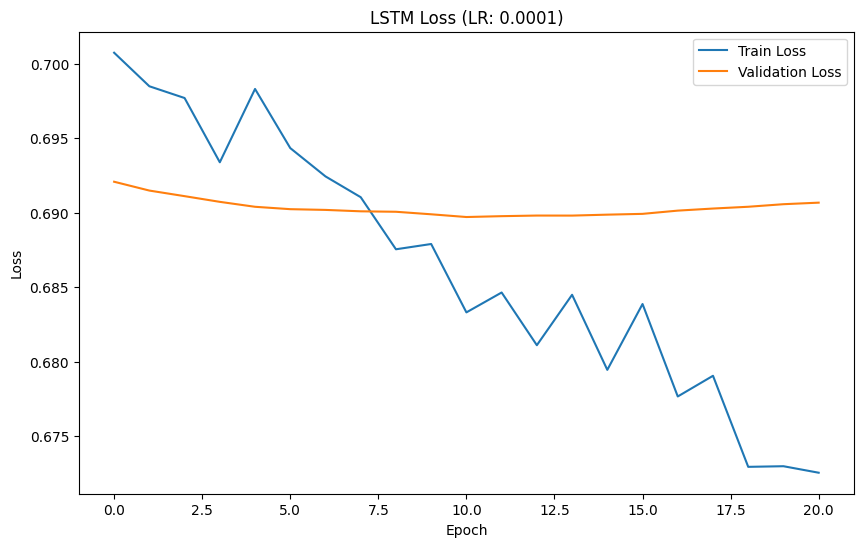

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

drop_outs = [0.1, 0.3, 0.5]
lrs = [1e-4, 1e-3, 5e-3, 1e-2]
window_size = 7

model = Sequential([
    LSTM(32, input_shape=(7, X_train_scaled.shape[2]), return_sequences=False),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy', optimizer=Adam(1e-4), metrics=['accuracy'])



# build EarlyStopping callback
early_stop = EarlyStopping(
    monitor='val_loss',   # 監控驗證集損失
    patience=10,           # 若連續 10 次 epoch 沒改善就停止
    restore_best_weights=True  # 回復到最佳權重
)

history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=16, callbacks=[early_stop],
                      validation_split=0.2, verbose=0, shuffle=False) # Set verbose to 0

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title(f'LSTM Loss (LR: {0.0001})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
# import matplotlib.pyplot as plt
# from tensorflow.keras.callbacks import EarlyStopping
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense, Dropout
# from tensorflow.keras.optimizers import Adam

# drop_outs = [0.1, 0.3, 0.5]
# lrs = [1e-4, 1e-3, 5e-3, 1e-2]
# window_size = 7

# results = []  # store results here

# for dp in drop_outs:
#     for lr in lrs:
#         print(f"Training model: dropout={dp}, lr={lr}")

#         model = Sequential([
#             LSTM(32, input_shape=(window_size, X_train_scaled.shape[2])),
#             Dropout(dp),
#             Dense(16, activation='relu'),
#             Dense(1, activation='sigmoid')
#         ])

#         model.compile(
#             loss='binary_crossentropy',
#             optimizer=Adam(lr),
#             metrics=['accuracy']
#         )

#         early_stop = EarlyStopping(
#             monitor='val_loss',
#             patience=10,
#             restore_best_weights=True
#         )

#         history = model.fit(
#             X_train_scaled, y_train,
#             epochs=50,
#             batch_size=16,
#             validation_split=0.2,
#             shuffle=False,
#             callbacks=[early_stop],
#             verbose=0
#         )

#         # evaluate
#         val_loss = min(history.history['val_loss'])
#         val_acc  = max(history.history['val_accuracy'])

#         results.append((dp, lr, val_loss, val_acc))

#         print(f" → Best Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")
#         print("-----")


In [ ]:
results_sorted = sorted(results, key=lambda x: x[2])  # sort by val_loss

for r in results_sorted:
    print(f"Dropout={r[0]}, LR={r[1]} → Val Loss={r[2]:.4f}, Val Acc={r[3]:.4f}")


Dropout=0.3, LR=0.001 → Val Loss=0.6861, Val Acc=0.5176
Dropout=0.1, LR=0.005 → Val Loss=0.6910, Val Acc=0.5647
Dropout=0.3, LR=0.0001 → Val Loss=0.6915, Val Acc=0.5529
Dropout=0.1, LR=0.01 → Val Loss=0.6929, Val Acc=0.5824
Dropout=0.3, LR=0.005 → Val Loss=0.6945, Val Acc=0.5412
Dropout=0.1, LR=0.0001 → Val Loss=0.6950, Val Acc=0.5412
Dropout=0.5, LR=0.001 → Val Loss=0.6982, Val Acc=0.5353
Dropout=0.5, LR=0.0001 → Val Loss=0.6982, Val Acc=0.4824
Dropout=0.1, LR=0.001 → Val Loss=0.7012, Val Acc=0.5118
Dropout=0.5, LR=0.01 → Val Loss=0.7032, Val Acc=0.5118
Dropout=0.5, LR=0.005 → Val Loss=0.7077, Val Acc=0.5118
Dropout=0.3, LR=0.01 → Val Loss=0.7199, Val Acc=0.5294


In [ ]:
# =============================
# Step 8: Evaluate
# =============================
from sklearn.metrics import f1_score
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.3f}")

# 簡單預測結果
y_pred = (model.predict(X_test) > 0.45).astype(int)
pred_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred.flatten()
})
y_score = model.predict(X_test).ravel()
print("min / max prob:", y_score.min(), y_score.max())

f1 = f1_score(y_test, y_pred)
print(f"F1 score: {f1:.3f}")
print(pred_df.head())

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4982 - loss: 0.6930 
Test Accuracy: 0.498
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
min / max prob: 0.4512893 0.52703565
F1 score: 0.685
   y_true  y_pred
0       1       1
1       0       1
2       1       1
3       1       1
4       0       1


## Transformer

Learning Rate: 0.0001


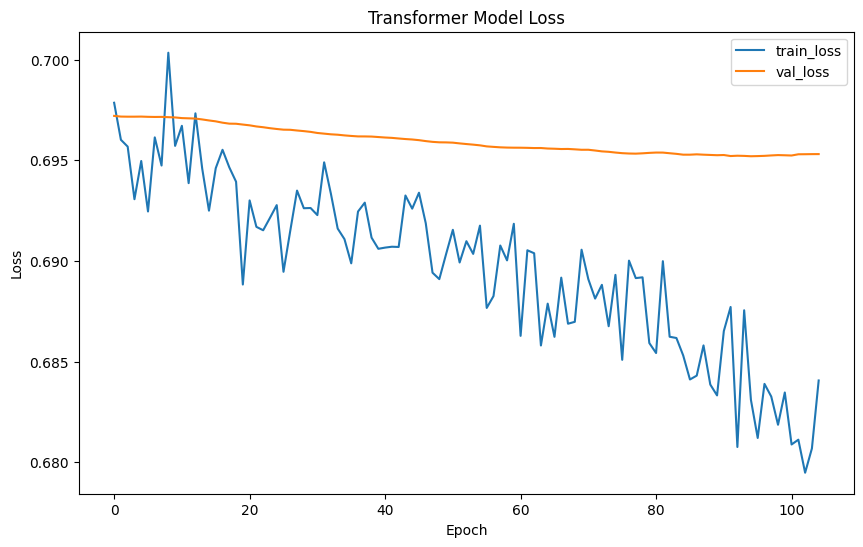

In [ ]:

# =============================
# Step 7: Build and Train Transformer
# =============================
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization
from tensorflow.keras.models import Model
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Normalization and Attention
    x = LayerNormalization(epsilon=1e-6)(inputs)
    attn_output = layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(x, x)
    x = layers.Dropout(dropout)(attn_output)
    res = x + inputs

    # Feed Forward Part
    x = LayerNormalization(epsilon=1e-6)(res)
    x = Dense(ff_dim, activation="relu")(x)
    x = Dense(inputs.shape[-1])(x)
    x = layers.Dropout(dropout)(x)
    return x + res

def build_transformer_model(input_shape, head_size, num_heads, ff_dim, num_transformer_blocks, mlp_units, dropout=0, mlp_dropout=0):
    inputs = Input(shape=input_shape)
    x = inputs
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    x = layers.GlobalAveragePooling1D(data_format="channels_first")(x)
    for dim in mlp_units:
        x = Dense(dim, activation="relu")(x)
        x = Dropout(mlp_dropout)(x)
    outputs = Dense(1, activation="sigmoid")(x)
    return Model(inputs, outputs)

# Define parameters
input_shape = (X_train.shape[1], X_train.shape[2])
head_size = 8
num_heads = 2
ff_dim = 16
num_transformer_blocks = 1
mlp_units = [8]
dropout = 0.3
mlp_dropout = 0.3
#lr: 1e-4, 1e-3, 5e-3,
lrs = [1e-4]

# build EarlyStopping callback
early_stop = EarlyStopping(
    monitor='val_loss',   # 監控驗證集損失
    patience=10,           # 若連續 10 次 epoch 沒改善就停止
    restore_best_weights=True  # 回復到最佳權重
)

for lr in lrs:
  print(f"Learning Rate: {lr}")

  # Build the model
  transformer_model = build_transformer_model(
      input_shape,
      head_size,
      num_heads,
      ff_dim,
      num_transformer_blocks,
      mlp_units,
      dropout,
      mlp_dropout
  )

  # Compile the model
  transformer_model.compile(
      loss="binary_crossentropy",
      optimizer=Adam(learning_rate=lr),
      metrics=["accuracy"]
  )

  # Train the model
  history_transformer = transformer_model.fit(
      X_train_scaled,
      y_train,
      epochs=500,  # Adjust epochs as needed
      batch_size=64, # Adjust batch size as needed
      validation_split=0.2,
      verbose=0,
      callbacks=[early_stop]
  )

  # Plot the loss
  plt.figure(figsize=(10, 6))
  plt.plot(history_transformer.history['loss'], label='train_loss')
  plt.plot(history_transformer.history['val_loss'], label='val_loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Transformer Model Loss')
  plt.legend()
  plt.show()




In [ ]:
# =============================
# Step 8: Evaluate
# =============================
from sklearn.metrics import f1_score
loss, acc = transformer_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.3f}")

# 簡單預測結果
y_pred = (transformer_model.predict(X_test) > 0.45).astype(int)
pred_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred.flatten()
})
print(pred_df.head())
print("f1 score", f1_score(y_test, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5018 - loss: 0.6926
Test Accuracy: 0.507
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step
   y_true  y_pred
0       1       1
1       1       1
2       0       1
3       1       1
4       0       1
f1 score 0.7341772151898734
